In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('heart_disease.csv')

In [3]:
df.sample(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
826,827,50,Male,VA Long Beach,asymptomatic,144.0,349.0,False,lv hypertrophy,120.0,True,1.0,upsloping,NaN,reversable defect,1
875,876,69,Male,VA Long Beach,asymptomatic,NaN,NaN,True,normal,NaN,NaN,NaN,NaN,NaN,NaN,2
654,655,56,Male,Switzerland,non-anginal,155.0,0.0,False,st-t abnormality,99.0,False,0.0,flat,NaN,normal,2
320,321,36,Male,Hungary,non-anginal,112.0,340.0,False,normal,184.0,False,1.0,flat,NaN,normal,0
449,450,54,Female,Hungary,atypical angina,160.0,312.0,False,normal,130.0,False,0.0,NaN,NaN,NaN,0
11,12,56,Female,Cleveland,atypical angina,140.0,294.0,False,lv hypertrophy,153.0,False,1.3,flat,0.0,normal,0
674,675,60,Male,Switzerland,non-anginal,115.0,0.0,NaN,normal,143.0,False,2.4,upsloping,NaN,NaN,1
362,363,43,Female,Hungary,typical angina,100.0,223.0,False,normal,142.0,False,0.0,NaN,NaN,NaN,0
304,305,29,Male,Hungary,atypical angina,120.0,243.0,False,normal,160.0,False,0.0,NaN,NaN,NaN,0
424,425,51,Male,Hungary,atypical angina,130.0,224.0,False,normal,150.0,False,0.0,NaN,NaN,NaN,0


In [4]:
df.shape

(920, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [6]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [7]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [8]:
df.isna().sum()[df.isna().sum()>0].sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64

In [9]:
print(f'No of duplicate Values = {df.duplicated().sum()}')

No of duplicate Values = 0


In [10]:
print('Max Age = ',df['age'].max())
print('Min Age = ',df['age'].min())
print('Avg Age = ',df['age'].mean().round(2))

Max Age =  77
Min Age =  28
Avg Age =  53.51


In [11]:
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [12]:
print("Male percentage = ",((df['sex']=='Male').sum()/920*100).round(2),"%")
print('Female percentage = ',((df['sex']=='Female').sum()/920*100).round(2),"%")

Male percentage =  78.91 %
Female percentage =  21.09 %


In [13]:
df['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [14]:
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [15]:
print("Most data has been collected from =",df['dataset'].value_counts().idxmax())

Most data has been collected from = Cleveland


In [16]:
df['cp'].unique()

array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)

In [17]:
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [18]:
print(f'Typical angina patient = {(df['cp']=='typical angina').sum()/920*100:.2f}%')
print(f'Atypical angina patient = {(df['cp']=='atypical angina').sum()/920*100:.2f}%')
print(f'Non-Anginal patient = {(df['cp']=='non-anginal').sum()/920*100:.2f}%')
print(f'Asymptomatic patient = {(df['cp']=='asymptomatic').sum()/920*100:.2f}%\n')
print("'Most Patient has No Chest Pain'")

Typical angina patient = 5.00%
Atypical angina patient = 18.91%
Non-Anginal patient = 22.17%
Asymptomatic patient = 53.91%

'Most Patient has No Chest Pain'


In [19]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [20]:
print('TrestBps = Blood pressure of the patient while resting\nNormal resting blood pressure is = 120 mm Hg\nHigher blood pressure(Hypertension)\n')
print(f"Average Resting blood pressure = {df['trestbps'].mean():.2f}")
print(f"Most Pateint's Resting bloodpressure = {df['trestbps'].mode()[0]}")
print("CONCLUSION\nMost patient's has Normal Blood Pressure")

TrestBps = Blood pressure of the patient while resting
Normal resting blood pressure is = 120 mm Hg
Higher blood pressure(Hypertension)

Average Resting blood pressure = 132.13
Most Pateint's Resting bloodpressure = 120.0
CONCLUSION
Most patient's has Normal Blood Pressure


In [21]:
print("Normal Cholestrol level < 200 mg/dl")
print(f"Most Patient's Cholestrol Level ={df['chol'].mode()}")

Normal Cholestrol level < 200 mg/dl
Most Patient's Cholestrol Level =0    0.0
Name: chol, dtype: float64


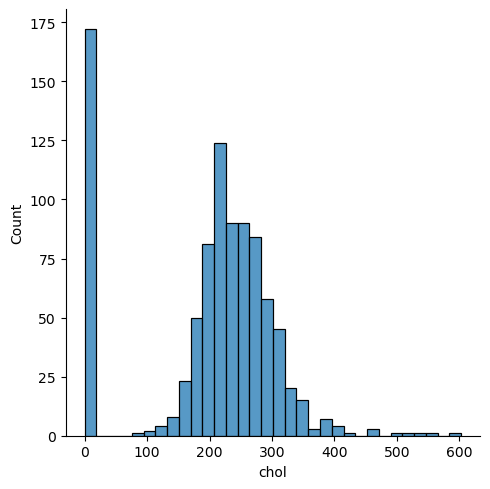

In [22]:
sns.displot(data=df,x='chol')

In [23]:
(df['chol']==0).sum()

np.int64(172)

In [24]:
df['chol'].describe()

count    890.000000
mean     199.130337
std      110.780810
min        0.000000
25%      175.000000
50%      223.000000
75%      268.000000
max      603.000000
Name: chol, dtype: float64

In [25]:
print(f"Fasting Blood Pressure > 120 mg/dl [True = 'Diabetes']\nFasting Blood Pressure < 120 mg/dl [False = 'Normal']")

Fasting Blood Pressure > 120 mg/dl [True = 'Diabetes']
Fasting Blood Pressure < 120 mg/dl [False = 'Normal']


In [26]:
print(f'Patient May have Diabetes = {(df['fbs']==True).sum()}')

Patient May have Diabetes = 138


In [27]:
print('Resting ECG\n   - Normal\n   - St-t Abnormality\n   - LV hypertrophy')

Resting ECG
   - Normal
   - St-t Abnormality
   - LV hypertrophy


In [28]:
print(f'Patient have Normal Rest ECG = {(df['restecg']=='normal').sum()}')
print(f'Patient have Abnoraml Rest ECG = {(df['restecg']=='st-t abnormality').sum()}')
print(f'Patient have LVH Rest ECG = {(df['restecg']=='lv hypertrophy').sum()}')

Patient have Normal Rest ECG = 551
Patient have Abnoraml Rest ECG = 179
Patient have LVH Rest ECG = 188
